<a href="https://colab.research.google.com/github/Eng-SHams-salah/Angular-Todo-List/blob/main/SkyShield_SHAP_Explainabilityy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SkyShield — SHAP Explainability Module

## Purpose
This notebook integrates **SHAP (SHapley Additive exPlanations)** into the SkyShield network-traffic classification pipeline. It provides:
- **Per-prediction explanations** — exactly *which* features pushed a packet toward 'malicious' or 'benign'
- **Global feature importance** — ranked across all samples for each sensor group
- **Four SHAP plot types**: Summary, Waterfall, Force, and Dependence

### How SHAP works
SHAP assigns each feature a Shapley value — a game-theory-based score measuring how much that feature contributed to shifting the model output away from the average prediction. Positive values push toward a class; negative values push away.

### Notebook structure
| Section | Content |
|---|---|
| 1 | Installation & imports |
| 2 | Load datasets, models, scalers |
| 3 | Build SHAP explainers (TreeExplainer + DeepExplainer) |
| 4 | Global feature importance (summary + beeswarm plots) |
| 5 | Per-prediction explanations (waterfall + force) |
| 6 | Feature dependence plots |
| 7 | TFT deep model explanations |
| 8 | `explain_prediction()` unified helper |
| 9 | Batch explanation report |
| 10 | Enhanced SkyShield alert with SHAP integration |

**1-Installation & imports**

In [ ]:
#  Install SHAP and supporting libraries
#  - shap       : core Shapley explanation library
#  - matplotlib : required for all SHAP plots
!pip install shap --quiet
!pip install matplotlib --quiet

In [ ]:
#  Core imports
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# shap.initjs() must be called once to enable interactive
# JavaScript force plots inside Jupyter / Colab notebooks.
shap.initjs()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device       : {device}')
print(f'SHAP version : {shap.__version__}')
print('All libraries ready')

Device       : cpu
SHAP version : 0.51.0
All libraries ready


---
## 2 — Load Datasets, Models & Scalers

reload all five sensor groups and their trained Random Forest and TFT models.
SHAP will be applied to **both** model types so explanations can be cross-compared.

| Group | Sensor / Protocol | Key features |
|---|---|---|
| G1 | WiFi Packets | packet_size, protocol_type, src/dst ports |
| G2 | Network Flow | flow_duration, byte_rate, traffic_frequency |
| G3 | MAVLink | command_type, sequence_no, payload_size |
| G4 | GPS Telemetry | lat, lon, altitude, speed, fix_quality |
| G5 | CAN Bus | can_id, dlc, data_bytes |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
base = '/content/drive/MyDrive/SkyShield_Datasets'

Mounted at /content/drive


In [ ]:

g1 = pd.read_csv(f'{base}/g1_wifi_packets.csv')
g2 = pd.read_csv(f'{base}/g2_network_flow.csv')
g3 = pd.read_csv(f'{base}/g3_mavlink.csv')
g4 = pd.read_csv(f'{base}/g4_gps.csv')
g5 = pd.read_csv(f'{base}/g5_canbus.csv')

datasets = {'G1': g1, 'G2': g2, 'G3': g3, 'G4': g4, 'G5': g5}
for name, df in datasets.items():
    print(f'{name}: {len(df):,} rows | {df.shape[1]} columns')

G1: 1,322,083 rows | 14 columns
G2: 111,425 rows | 11 columns
G3: 379,739 rows | 9 columns
G4: 6,445 rows | 83 columns
G5: 2,032,530 rows | 5 columns


In [ ]:
#  Load Random Forest models, scalers, and label encoders.
#  RF models pair with TreeExplainer — the most accurate and
#  fastest SHAP method for tree-based ensembles.
rf_models  = {}
rf_scalers = {}
rf_les     = {}

for i, gname in enumerate(['G1', 'G2', 'G3', 'G4', 'G5'], start=1):
    try:
        with open(f'{base}/rf_g{i}.pkl',     'rb') as f: rf_models[gname]  = pickle.load(f)
        with open(f'{base}/scaler_g{i}.pkl', 'rb') as f: rf_scalers[gname] = pickle.load(f)
        with open(f'{base}/le_g{i}.pkl',     'rb') as f: rf_les[gname]     = pickle.load(f)
        print(f'  {gname} RF loaded | {len(rf_les[gname].classes_)} classes')
    except FileNotFoundError as e:
        print(f'  {gname} RF not found: {e}')

print('\nRandom Forest models ready')

  G1 RF loaded | 14 classes
  G2 RF loaded | 14 classes
  G3 RF loaded | 6 classes
  G4 RF loaded | 2 classes
  G5 RF loaded | 8 classes

Random Forest models ready


In [ ]:
#  Re-define CustomTFT so saved .pth weights can be loaded.
#  Architecture must match what was used during training.
class CustomTFT(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, num_heads=4, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_size, hidden_size)
        self.lstm = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size,
                            num_layers=2, batch_first=True, dropout=dropout)
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size, num_heads=num_heads,
            dropout=dropout, batch_first=True)
        self.gate = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size), nn.Sigmoid())
        self.norm = nn.LayerNorm(hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_size // 2, num_classes))

    def forward(self, x):
        x = self.input_projection(x)
        lstm_out, _ = self.lstm(x)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        gate_w = self.gate(torch.cat([lstm_out, attn_out], dim=-1))
        gated  = gate_w * lstm_out + (1 - gate_w) * attn_out
        return self.classifier(self.norm(gated)[:, -1, :])

group_configs = {
    'G1': {'input_size': 12, 'hidden_size': 64},
    'G2': {'input_size':  9, 'hidden_size': 64},
    'G3': {'input_size':  7, 'hidden_size': 128},
    'G4': {'input_size': 81, 'hidden_size': 64},
    'G5': {'input_size':  3, 'hidden_size': 64},
}

tft_models  = {}
tft_scalers = {}
tft_les     = {}

for gname, cfg in group_configs.items():
    try:
        with open(f'{base}/tft_scaler_{gname.lower()}.pkl', 'rb') as f:
            tft_scalers[gname] = pickle.load(f)
        with open(f'{base}/tft_le_{gname.lower()}.pkl', 'rb') as f:
            tft_les[gname] = pickle.load(f)
        n_cls = len(tft_les[gname].classes_)
        m = CustomTFT(cfg['input_size'], cfg['hidden_size'], n_cls).to(device)
        m.load_state_dict(torch.load(
            f'{base}/tft_{gname.lower()}.pth', map_location=device))
        m.eval()
        tft_models[gname] = m
        print(f'  {gname} TFT loaded | {n_cls} classes')
    except FileNotFoundError as e:
        print(f'  {gname} TFT not found: {e}')

print('\nTFT models ready')

  G1 TFT loaded | 14 classes
  G2 TFT loaded | 14 classes
  G3 TFT loaded | 6 classes
  G4 TFT loaded | 2 classes
  G5 TFT loaded | 8 classes

TFT models ready


In [ ]:
#  Feature preparation helper.
#  Extracts numeric features from a group DataFrame and
#  applies the pre-trained MinMaxScaler used at training time
def prepare_features(df, scaler, n_features=None):
    df2 = df.copy()
    df2.columns = df2.columns.str.replace('.', '_', regex=False)
    exclude = {'label_encoded', 'attack_type'}
    feat_cols = [
        c for c in df2.columns
        if c not in exclude
        and df2[c].dtype in ['float64', 'int64', 'float32', 'int32']
    ]
    if n_features is not None:
        feat_cols = feat_cols[:n_features]
    X  = df2[feat_cols].values
    y  = df2['label_encoded'].values if 'label_encoded' in df2.columns else None
    return scaler.transform(X), y, feat_cols

print('prepare_features() ready')

---
## 3 — Build SHAP Explainers

| Explainer | Best for | Notes |
|---|---|---|
| `TreeExplainer` | Random Forest | Exact, very fast |
| `DeepExplainer` | PyTorch TFT | Approximate, uses background set |
| `KernelExplainer` | Any black-box | Slow, model-agnostic fallback |

In [ ]:
#  TreeExplainer — one per Random Forest model.
#  TreeExplainer traverses the decision trees to compute
#  exact Shapley values without any sampling approximation.
tree_explainers = {}
for gname, model in rf_models.items():
    tree_explainers[gname] = shap.TreeExplainer(model)
    print(f'  TreeExplainer ready for {gname}')
print('\nAll TreeExplainers ready')

  TreeExplainer ready for G1
  TreeExplainer ready for G2
  TreeExplainer ready for G3
  TreeExplainer ready for G4
  TreeExplainer ready for G5

All TreeExplainers ready


In [ ]:
#  TFTWrapper — adapts the 3-D TFT interface to 2-D so
#  DeepExplainer can pass flat (batch x features) tensors.
#  Each row is tiled SEQ_LEN times to form a sequence.

SEQ_LEN = 50

class TFTWrapper(nn.Module):
    """
    Wraps CustomTFT so SHAP's DeepExplainer can work with
    flat 2-D input (batch x features) instead of sequences.
    Internally tiles each sample into (batch, seq_len, features).
    """
    def __init__(self, tft_model, seq_len):
        super().__init__()
        self.model   = tft_model
        self.seq_len = seq_len

    def forward(self, x):
        # x: (batch, features)  →  (batch, seq_len, features)
        return self.model(x.unsqueeze(1).repeat(1, self.seq_len, 1))


BACKGROUND_N = 100

deep_explainers  = {}
deep_backgrounds = {}

for gname, model in tft_models.items():
    cfg    = group_configs[gname]
    scaler = tft_scalers[gname]
    X_sc, _, _ = prepare_features(datasets[gname], scaler,
                                   n_features=cfg['input_size'])
    idx  = np.random.choice(len(X_sc),
                             size=min(BACKGROUND_N, len(X_sc)),
                             replace=False)
    bg_np = X_sc[idx].astype(np.float32)
    bg_t  = torch.tensor(bg_np).to(device)
    deep_backgrounds[gname] = bg_np

    wrapped = TFTWrapper(model, SEQ_LEN).to(device)
    wrapped.eval()
    deep_explainers[gname] = shap.DeepExplainer(wrapped, bg_t)
    print(f'  DeepExplainer ready for {gname} (background: {len(bg_np)} samples)')

print('\nAll DeepExplainers ready')

  DeepExplainer ready for G1 (background: 100 samples)
  DeepExplainer ready for G2 (background: 100 samples)
  DeepExplainer ready for G3 (background: 100 samples)
  DeepExplainer ready for G4 (background: 100 samples)
  DeepExplainer ready for G5 (background: 100 samples)

All DeepExplainers ready


**4- Global feature importance (summary + beeswarm plots)**

Mounted at /content/drive
Successfully loaded G1
Successfully loaded G2
Successfully loaded G3
Successfully loaded G4
Successfully loaded G5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


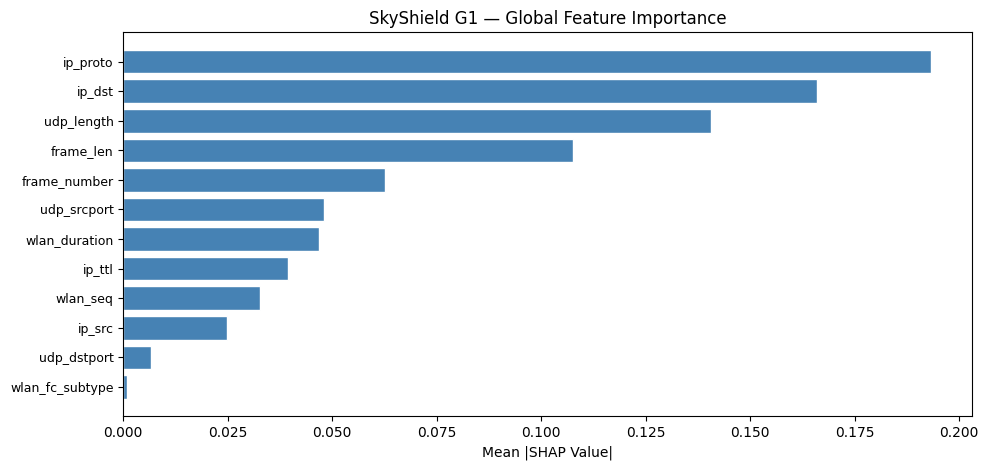

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


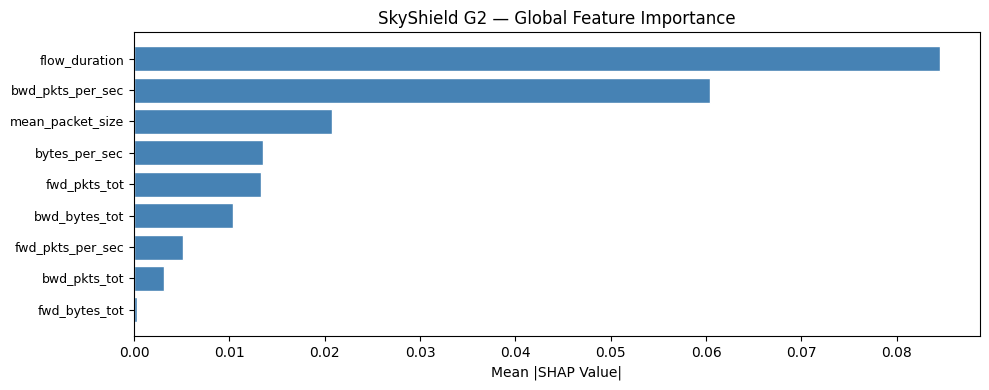

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


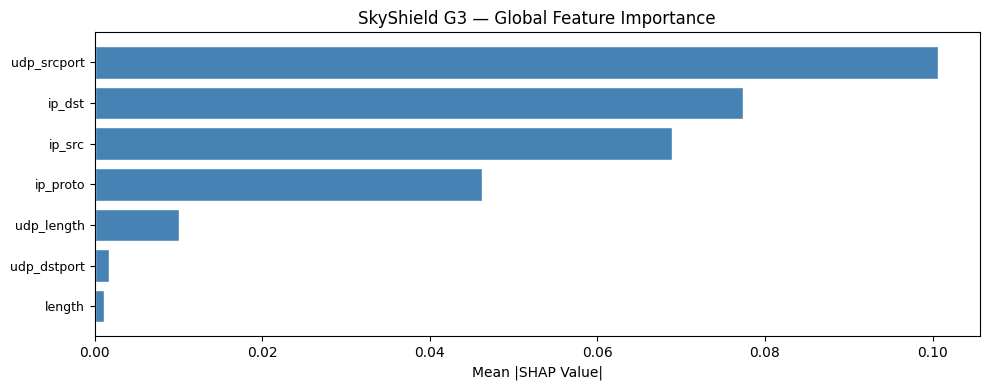

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


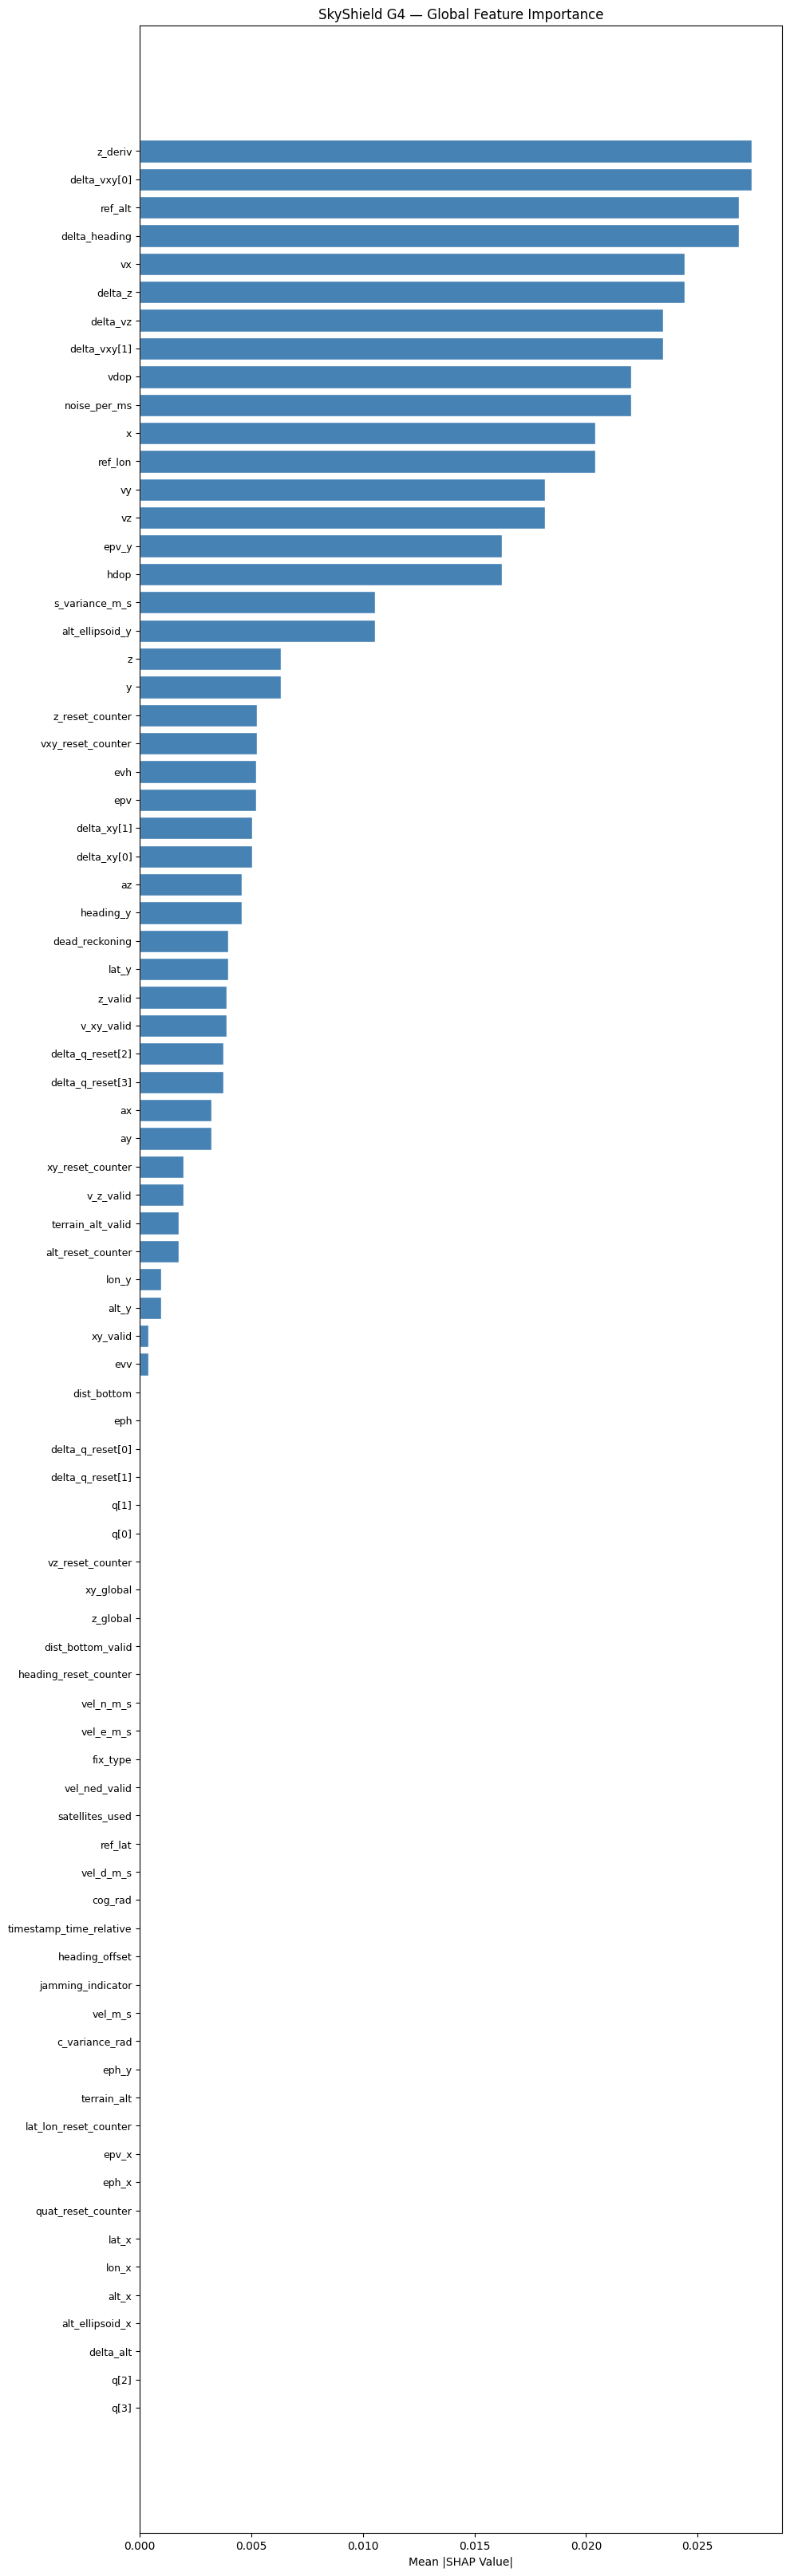

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


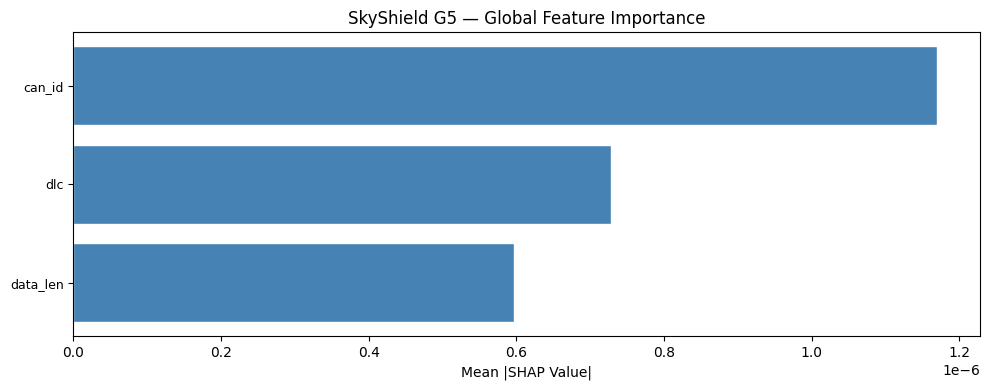

In [3]:
#  GLOBAL SUMMARY BAR CHARTS — Random Forest
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

base = '/content/drive/MyDrive/SkyShield_Datasets'

def prepare_features(df, scaler, n_features=None):
    df2 = df.copy()
    df2.columns = df2.columns.str.replace('.', '_', regex=False)
    exclude = {'label_encoded', 'attack_type'}
    feat_cols = [c for c in df2.columns if c not in exclude and df2[c].dtype in ['float64', 'int64', 'float32', 'int32']]
    if n_features is not None: feat_cols = feat_cols[:n_features]
    X = df2[feat_cols].values
    return scaler.transform(X), feat_cols

rf_models, rf_scalers, datasets, tree_explainers = {}, {}, {}, {}
group_info = {'G1': 'wifi_packets', 'G2': 'network_flow', 'G3': 'mavlink', 'G4': 'gps', 'G5': 'canbus'}

for i, gname in enumerate(['G1', 'G2', 'G3', 'G4', 'G5'], start=1):
    try:
        with open(f'{base}/rf_g{i}.pkl', 'rb') as f: rf_models[gname] = pickle.load(f)
        with open(f'{base}/scaler_g{i}.pkl', 'rb') as f: rf_scalers[gname] = pickle.load(f)
        datasets[gname] = pd.read_csv(f'{base}/g{i}_{group_info[gname]}.csv')
        tree_explainers[gname] = shap.TreeExplainer(rf_models[gname])
        print(f"Successfully loaded {gname}")
    except Exception as e:
        print(f"Could not load {gname}: {e}")

SUMMARY_N = 500
for gname in [g for g in ['G1','G2','G3','G4','G5'] if g in rf_models]:
    X_sc, feat_cols = prepare_features(datasets[gname], rf_scalers[gname])
    idx = np.random.choice(len(X_sc), size=min(SUMMARY_N, len(X_sc)), replace=False)
    X_sub = X_sc[idx]
    shap_vals = tree_explainers[gname].shap_values(X_sub)

    if isinstance(shap_vals, list):
        mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    else:
        mean_abs = np.abs(shap_vals).mean(axis=0)

    mean_abs = mean_abs.flatten()
    num_f = min(len(feat_cols), len(mean_abs))
    plot_vals, plot_cols = mean_abs[:num_f], feat_cols[:num_f]
    sorted_idx = np.argsort(plot_vals)

    plt.figure(figsize=(10, max(4, num_f * 0.4)))
    plt.barh(range(num_f), plot_vals[sorted_idx], color='steelblue', edgecolor='white')
    plt.yticks(range(num_f), [plot_cols[i] for i in sorted_idx], fontsize=9)
    plt.xlabel('Mean |SHAP Value|')
    plt.title(f'SkyShield {gname} — Global Feature Importance')
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


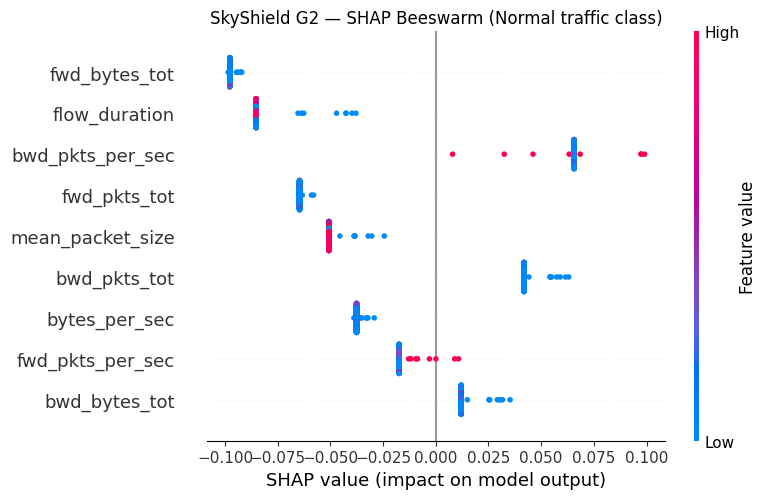

Beeswarm plot saved successfully.


In [6]:

#  BEESWARM SUMMARY PLOT — G2 Network Flow
#  The beeswarm shows the full SHAP distribution, not just the mean
#   Each dot = one sample. Colour = feature value.
#  Red dots on the right = high feature value pushes model
#  strongly toward the selected class
GNAME = 'G2'

X_sc, feat_cols = prepare_features(datasets[GNAME], rf_scalers[GNAME])

idx   = np.random.choice(len(X_sc), size=300, replace=False)
X_sub = X_sc[idx]
sv    = tree_explainers[GNAME].shap_values(X_sub)

# Use class-0 (Normal traffic) SHAP values
# Positive SHAP → increases P(Normal); negative → increases P(attack)
sv0 = sv[0] if isinstance(sv, list) else sv

plt.figure(figsize=(10, 6))
shap.summary_plot(sv0, X_sub, feature_names=feat_cols,
                  plot_type='dot', max_display=15, show=False)
plt.title(f'SkyShield {GNAME} — SHAP Beeswarm (Normal traffic class)', fontsize=12)
plt.tight_layout()
plt.savefig(f'shap_beeswarm_{GNAME}_rf.png', dpi=120, bbox_inches='tight')
plt.show()
print('Beeswarm plot saved')

---
##5 — Per-Prediction Explanations

### 5a — Waterfall Plot
Shows how each feature pushed a single prediction from the baseline (average prediction) to the final output.

**How to read:**
- **Left baseline** `E[f(x)]` = average model output over all training samples
- **Right value** `f(x)` = model's actual output for this packet
- **Red bars** = features increasing the predicted class probability
- **Blue bars** = features decreasing the predicted class probability

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


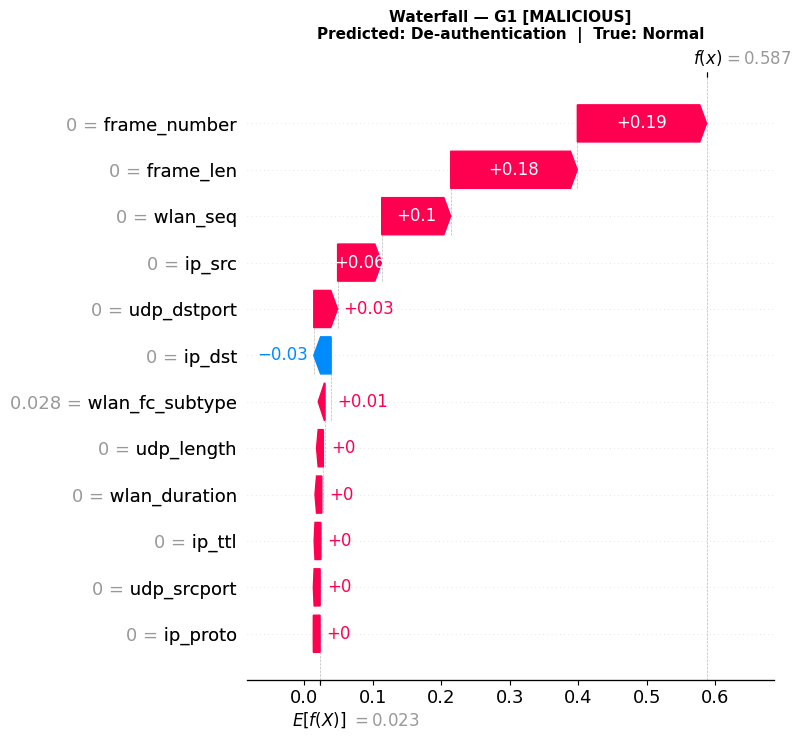


  [MALICIOUS] Predicted: "De-authentication" | True: "Normal"
  Feature                                 SHAP   Direction
  ----------------------------------- --------   ─────────
  frame_number                         +0.1887   ATTACK ↑
  frame_len                            +0.1848   ATTACK ↑
  wlan_seq                             +0.1007   ATTACK ↑
  ip_src                               +0.0644   ATTACK ↑
  udp_dstport                          +0.0348   ATTACK ↑
  ip_dst                               -0.0253   NORMAL ↓
  wlan_fc_subtype                      +0.0090   ATTACK ↑
  udp_length                           +0.0024   ATTACK ↑



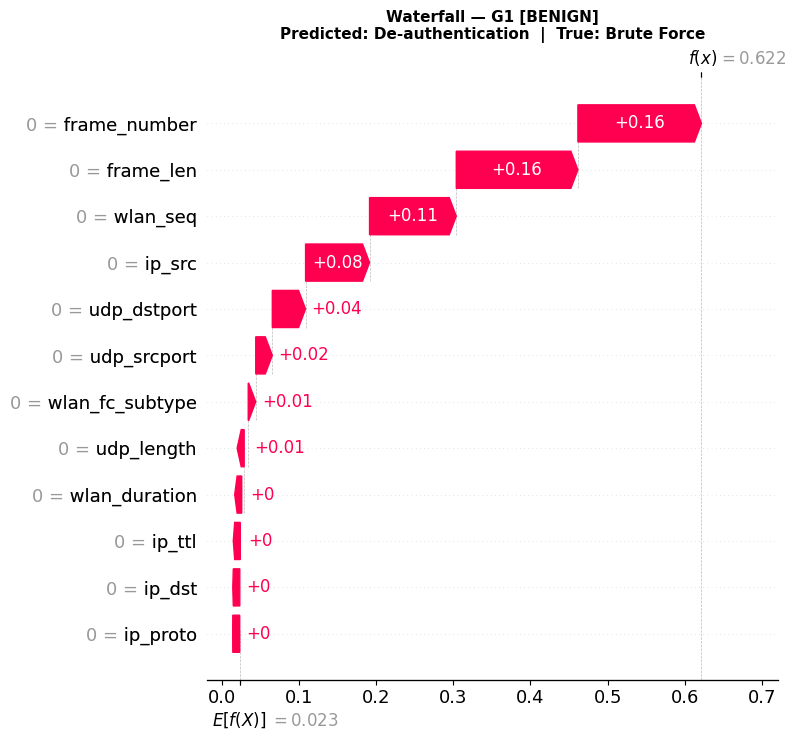


  [BENIGN] Predicted: "De-authentication" | True: "Brute Force"
  Feature                                 SHAP   Direction
  ----------------------------------- --------   ─────────
  frame_number                         +0.1601   ATTACK ↑
  frame_len                            +0.1576   ATTACK ↑
  wlan_seq                             +0.1124   ATTACK ↑
  ip_src                               +0.0829   ATTACK ↑
  udp_dstport                          +0.0431   ATTACK ↑
  udp_srcport                          +0.0215   ATTACK ↑
  wlan_fc_subtype                      +0.0097   ATTACK ↑
  udp_length                           +0.0053   ATTACK ↑



In [9]:
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import os

def prepare_features(df, scaler, n_features=None):
    df2 = df.copy()
    df2.columns = df2.columns.str.replace('.', '_', regex=False)
    exclude = {'label_encoded', 'attack_type'}
    feat_cols = [
        c for c in df2.columns
        if c not in exclude
        and df2[c].dtype in ['float64', 'int64', 'float32', 'int32']
    ]
    if n_features is not None:
        feat_cols = feat_cols[:n_features]
    X  = df2[feat_cols].values
    y  = df2['label_encoded'].values if 'label_encoded' in df2.columns else None
    return scaler.transform(X), y, feat_cols

GNAME = 'G1'
base = '/content/drive/MyDrive/SkyShield_Datasets'

if 'rf_les' not in globals() or GNAME not in rf_les:
    rf_les = {}
    for i, name in enumerate(['G1', 'G2', 'G3', 'G4', 'G5'], start=1):
        le_path = f'{base}/le_g{i}.pkl'
        if os.path.exists(le_path):
            with open(le_path, 'rb') as f: rf_les[name] = pickle.load(f)

X_sc, y, feat_cols = prepare_features(datasets[GNAME], rf_scalers[GNAME])
rf_model  = rf_models[GNAME]
explainer = tree_explainers[GNAME]
le        = rf_les[GNAME]

mal_idx = int(np.where(y != 0)[0][0])
nor_idx = int(np.where(y == 0)[0][0])

for sample_idx, title in [(mal_idx, 'MALICIOUS'), (nor_idx, 'BENIGN')]:

    row_2d = X_sc[[sample_idx]]
    pred_class = rf_model.predict(row_2d)[0]
    pred_label = le.inverse_transform([pred_class])[0]
    true_label = le.inverse_transform([y[sample_idx]])[0]


    sv = explainer.shap_values(row_2d)

    if isinstance(sv, list):

        sv_pred = sv[pred_class][0]
    else:

        if sv.ndim == 3:
            sv_pred = sv[0, :, pred_class]
        else:
            sv_pred = sv[0]

    if isinstance(explainer.expected_value, (list, np.ndarray)):
        ev = explainer.expected_value[pred_class]
    else:
        ev = explainer.expected_value

    explanation = shap.Explanation(
        values=sv_pred.flatten(),
        base_values=float(ev),
        data=X_sc[sample_idx].flatten(),
        feature_names=feat_cols
    )

    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(
        f'Waterfall — {GNAME} [{title}]\nPredicted: {pred_label}  |  True: {true_label}',
        fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    contributions = sorted(zip(feat_cols, sv_pred.flatten()),
                           key=lambda x: abs(x[1]), reverse=True)
    print(f'\n  [{title}] Predicted: "{pred_label}" | True: "{true_label}"')
    print(f'  {"Feature":<35} {"SHAP":>8}   Direction')
    print(f'  {"-"*35} {"-"*8}   ─────────')
    for feat, val in contributions[:8]:
        arrow = "ATTACK ↑" if val > 0 else "NORMAL ↓"
        print(f'  {feat:<35} {val:>+8.4f}   {arrow}')
    print()

### 5b — Force Plot
A compact horizontal view of the same single-prediction explanation. Features in **red** push toward the predicted class; **blue** push away. Hover over bars in the interactive version to see exact values.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Sample #5 | True: Normal | Predicted: DoS


<Figure size 1200x300 with 0 Axes>

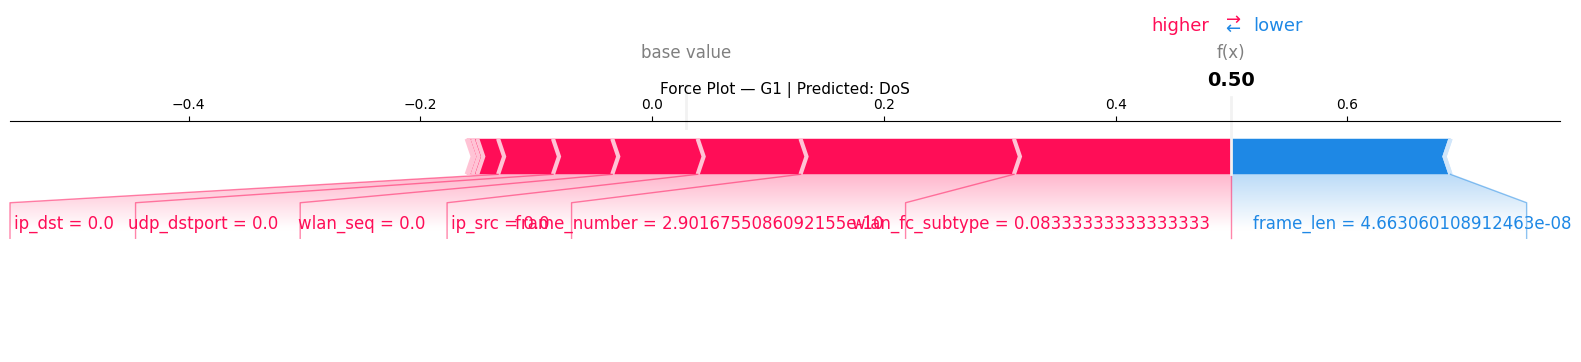

In [12]:
#  FORCE PLOT — interactive + static PNG version
#  shap.force_plot() renders an interactive HTML widget in
#  Colab/Jupyter. We also produce a static matplotlib version
#  for reports or non-interactive environments.
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from google.colab import drive
from IPython.display import display

shap.initjs()

try:
    drive.mount('/content/drive')
except Exception:
    pass

base = '/content/drive/MyDrive/SkyShield_Datasets'

GNAME = 'G1'
X_sc, y, feat_cols = prepare_features(datasets[GNAME], rf_scalers[GNAME])
rf_model  = rf_models[GNAME]
explainer = tree_explainers[GNAME]
le        = rf_les[GNAME]


sample_idx = int(np.where(y != 0)[0][5])
row_2d = X_sc[[sample_idx]]
pred_class = rf_model.predict(row_2d)[0]
pred_label = le.inverse_transform([pred_class])[0]
true_label = le.inverse_transform([y[sample_idx]])[0]

sv = explainer.shap_values(row_2d)
if isinstance(sv, list):
    sv_s = sv[pred_class][0]
else:
    sv_s = sv[0, :, pred_class] if sv.ndim == 3 else sv[0]

if isinstance(explainer.expected_value, (list, np.ndarray)):
    ev = explainer.expected_value[pred_class]
else:
    ev = explainer.expected_value

print(f'Sample #{sample_idx} | True: {true_label} | Predicted: {pred_label}')

force_plot = shap.force_plot(
    float(ev),
    sv_s.flatten(),
    X_sc[sample_idx].flatten(),
    feature_names=feat_cols
)
display(force_plot)

try:
    plt.figure(figsize=(12, 3))
    shap.force_plot(
        float(ev),
        sv_s.flatten(),
        X_sc[sample_idx].flatten(),
        feature_names=feat_cols,
        matplotlib=True,
        show=False
    )
    plt.title(f'Force Plot — {GNAME} | Predicted: {pred_label}', fontsize=11, pad=20)
    plt.savefig(f'shap_force_{GNAME}.png', dpi=120, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Static plot skipped or failed: {e}")

---
##6 — Feature Dependence Plots

A **dependence plot** reveals how a feature's value relates to its SHAP contribution:
- **x-axis** = scaled feature value
- **y-axis** = SHAP value for that feature
- **Colour** = value of the most interacting second feature

Non-linear curves indicate the feature has context-dependent effects (e.g., `packet_size` only matters when `protocol_type` is also abnormal).

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


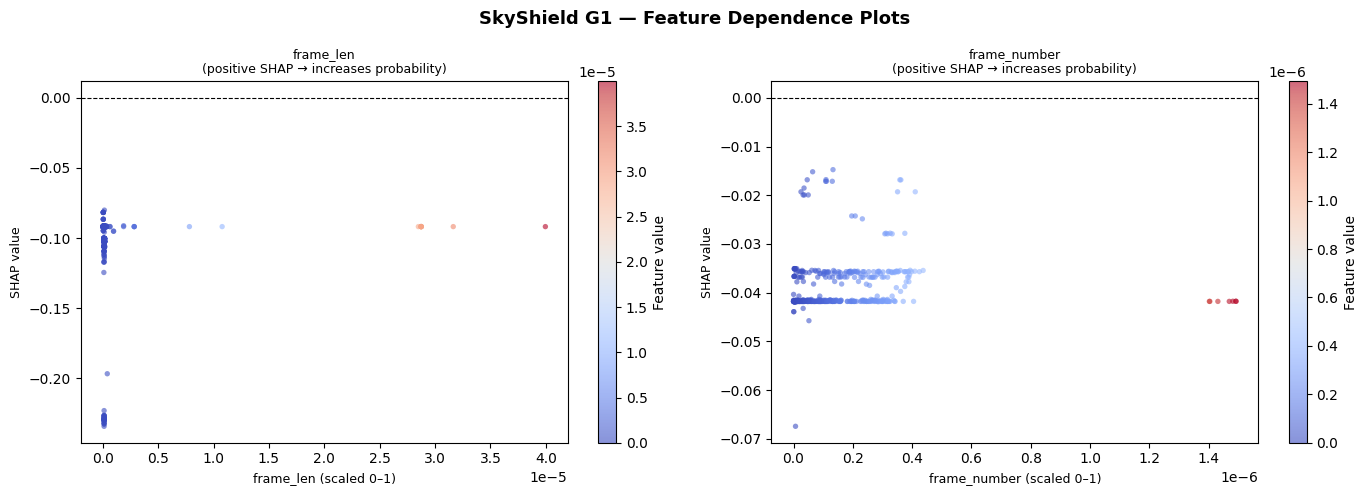

G1 dependence plots: frame_len, frame_number



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


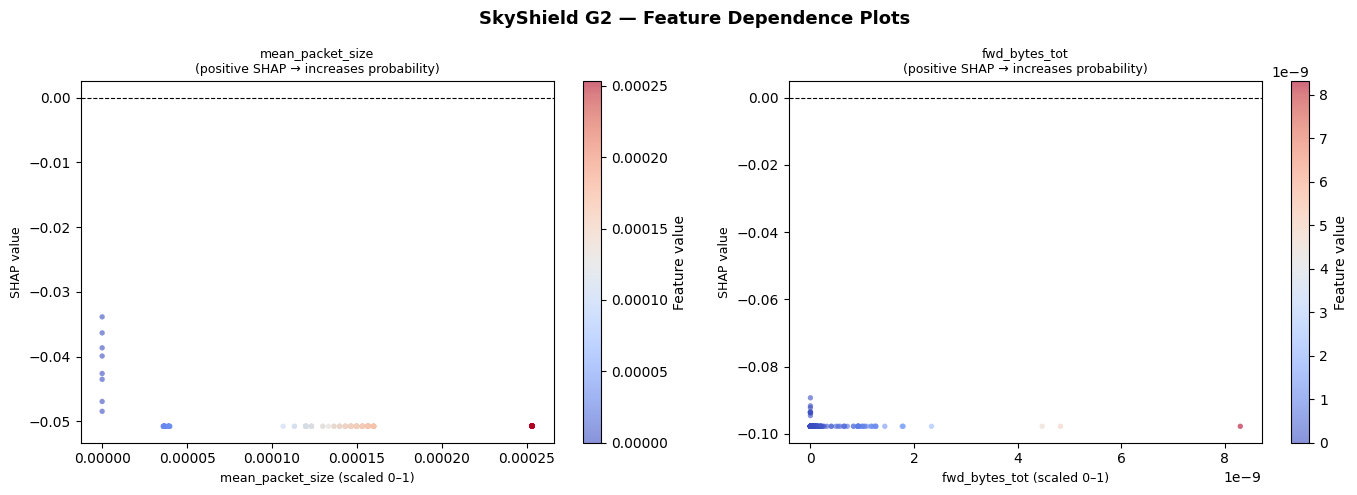

G2 dependence plots: mean_packet_size, fwd_bytes_tot



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


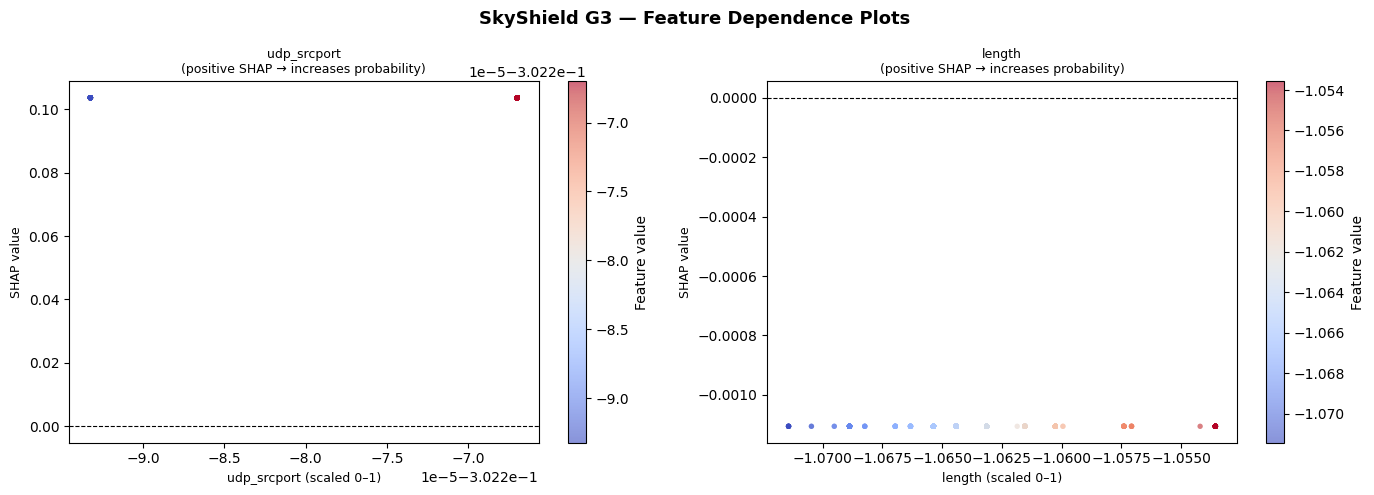

G3 dependence plots: udp_srcport, length



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


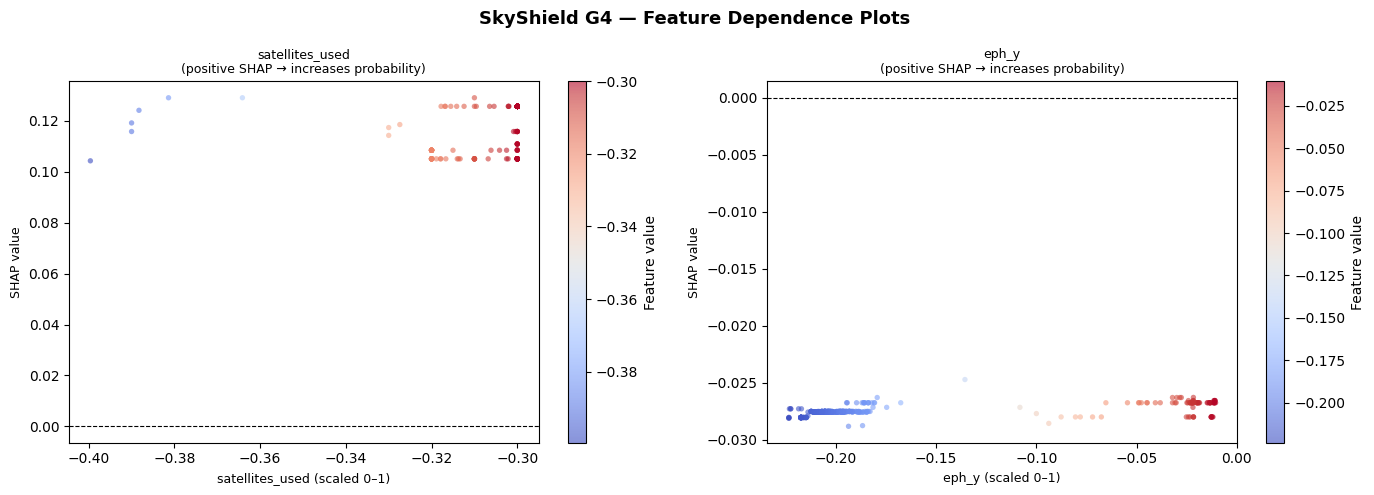

G4 dependence plots: satellites_used, eph_y



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


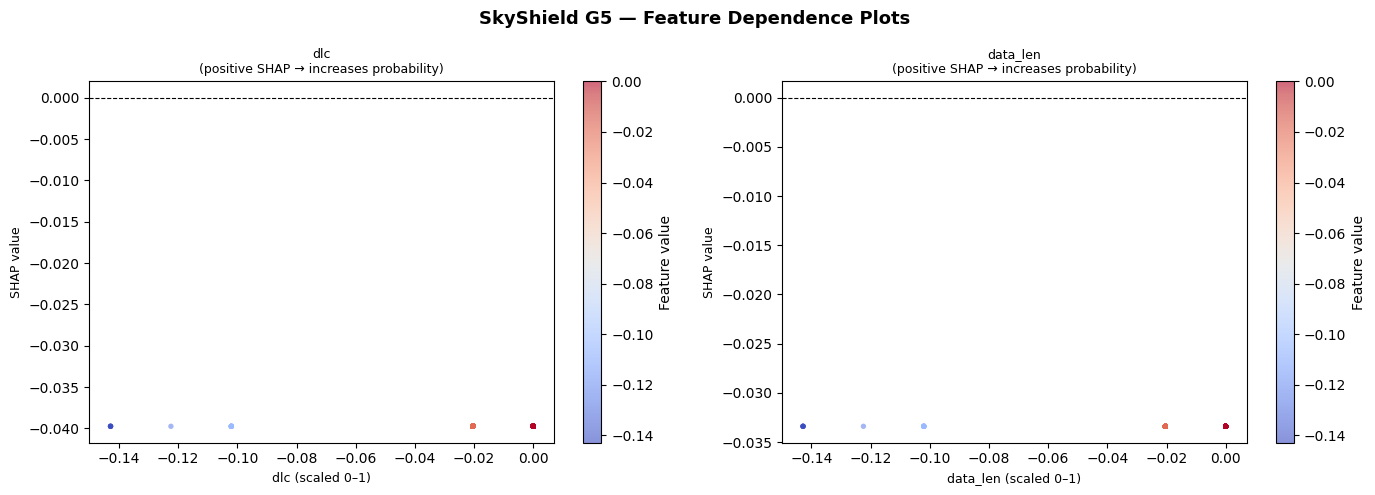

G5 dependence plots: dlc, data_len



In [14]:
DEP_N = 400

for gname in rf_models:
    X_sc, y, feat_cols = prepare_features(datasets[gname], rf_scalers[gname])
    idx  = np.random.choice(len(X_sc), size=min(DEP_N, len(X_sc)), replace=False)
    X_s  = X_sc[idx]
    sv   = tree_explainers[gname].shap_values(X_s)

    # Multi-class handling: mean importance across all classes to find top features
    if isinstance(sv, list):
        # sv is list of [N, features] arrays
        mean_abs = np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
        sv_plot  = sv[0]
    else:
        # sv is [N, features, classes] or [N, features]
        if sv.ndim == 3:
            mean_abs = np.abs(sv).mean(axis=(0, 2))
            sv_plot  = sv[:, :, 0]
        else:
            mean_abs = np.abs(sv).mean(axis=0)
            sv_plot  = sv

    top2    = np.argsort(mean_abs.flatten())[::-1][:2]
    feat_a  = feat_cols[top2[0]]
    feat_b  = feat_cols[top2[1]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'SkyShield {gname} — Feature Dependence Plots',
                 fontsize=13, fontweight='bold')

    for ax, fname in zip(axes, [feat_a, feat_b]):
        fi  = feat_cols.index(fname)
        sc  = ax.scatter(X_s[:, fi], sv_plot[:, fi],
                         c=X_s[:, fi], cmap='coolwarm',
                         alpha=0.6, edgecolors='none', s=15)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel(f'{fname} (scaled 0–1)', fontsize=9)
        ax.set_ylabel('SHAP value', fontsize=9)
        ax.set_title(
            f'{fname}\n(positive SHAP → increases probability)',
            fontsize=9)
        plt.colorbar(sc, ax=ax, label='Feature value')

    plt.tight_layout()
    plt.savefig(f'shap_dependence_{gname}_rf.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'{gname} dependence plots: {feat_a}, {feat_b}\n')

---
7 — **TFT Deep Model Explanations**

DeepExplainer computes SHAP values for the TFT by backpropagating DeepLIFT-style gradients from each output neuron through the network. Compare these with the RF explanations to see if both models agree on which features are important.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LayerNorm
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


<Figure size 1000x500 with 0 Axes>

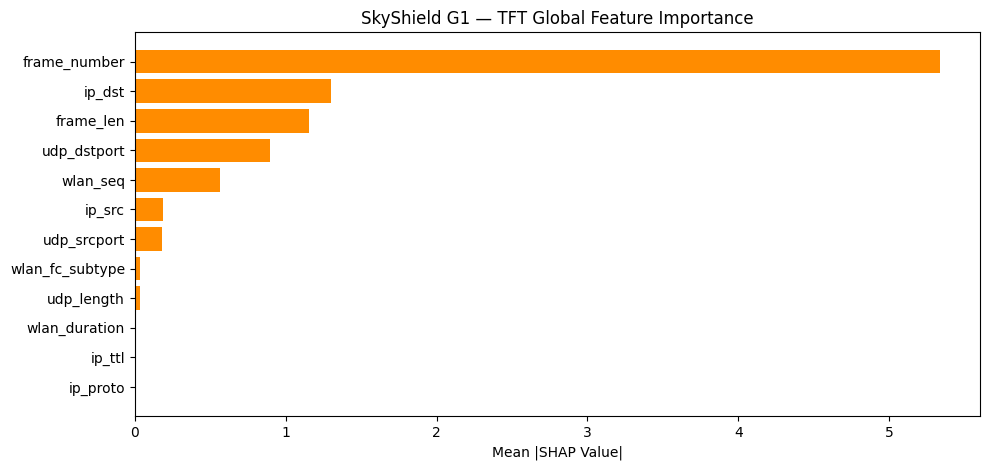

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LayerNorm
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


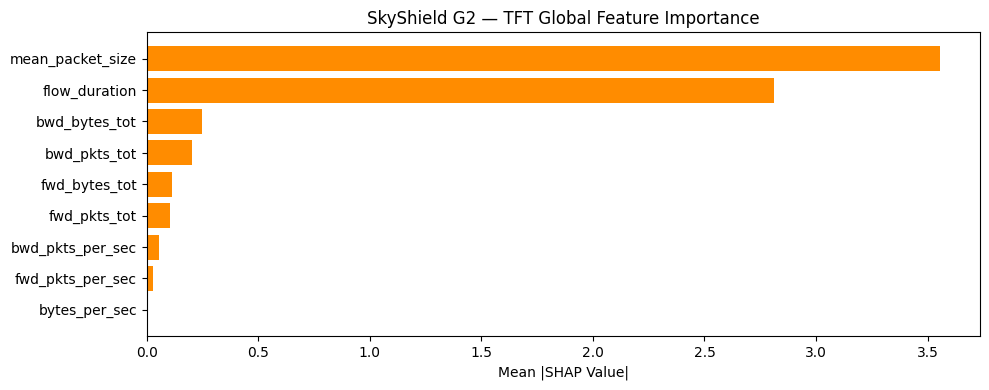

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LayerNorm
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


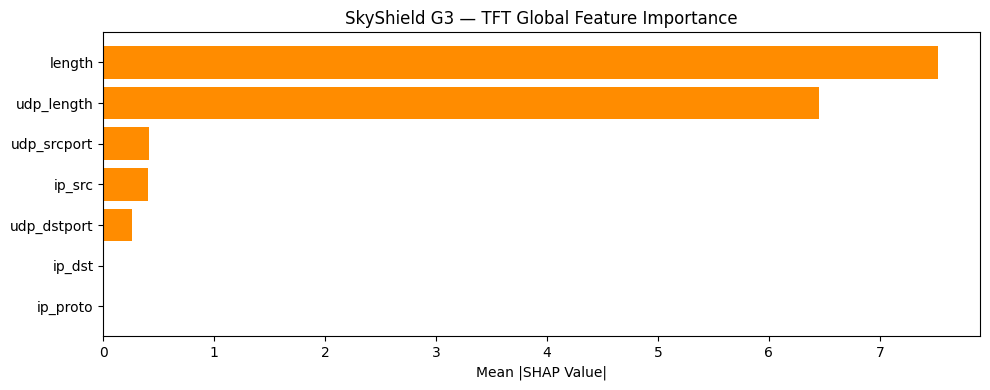

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LayerNorm
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


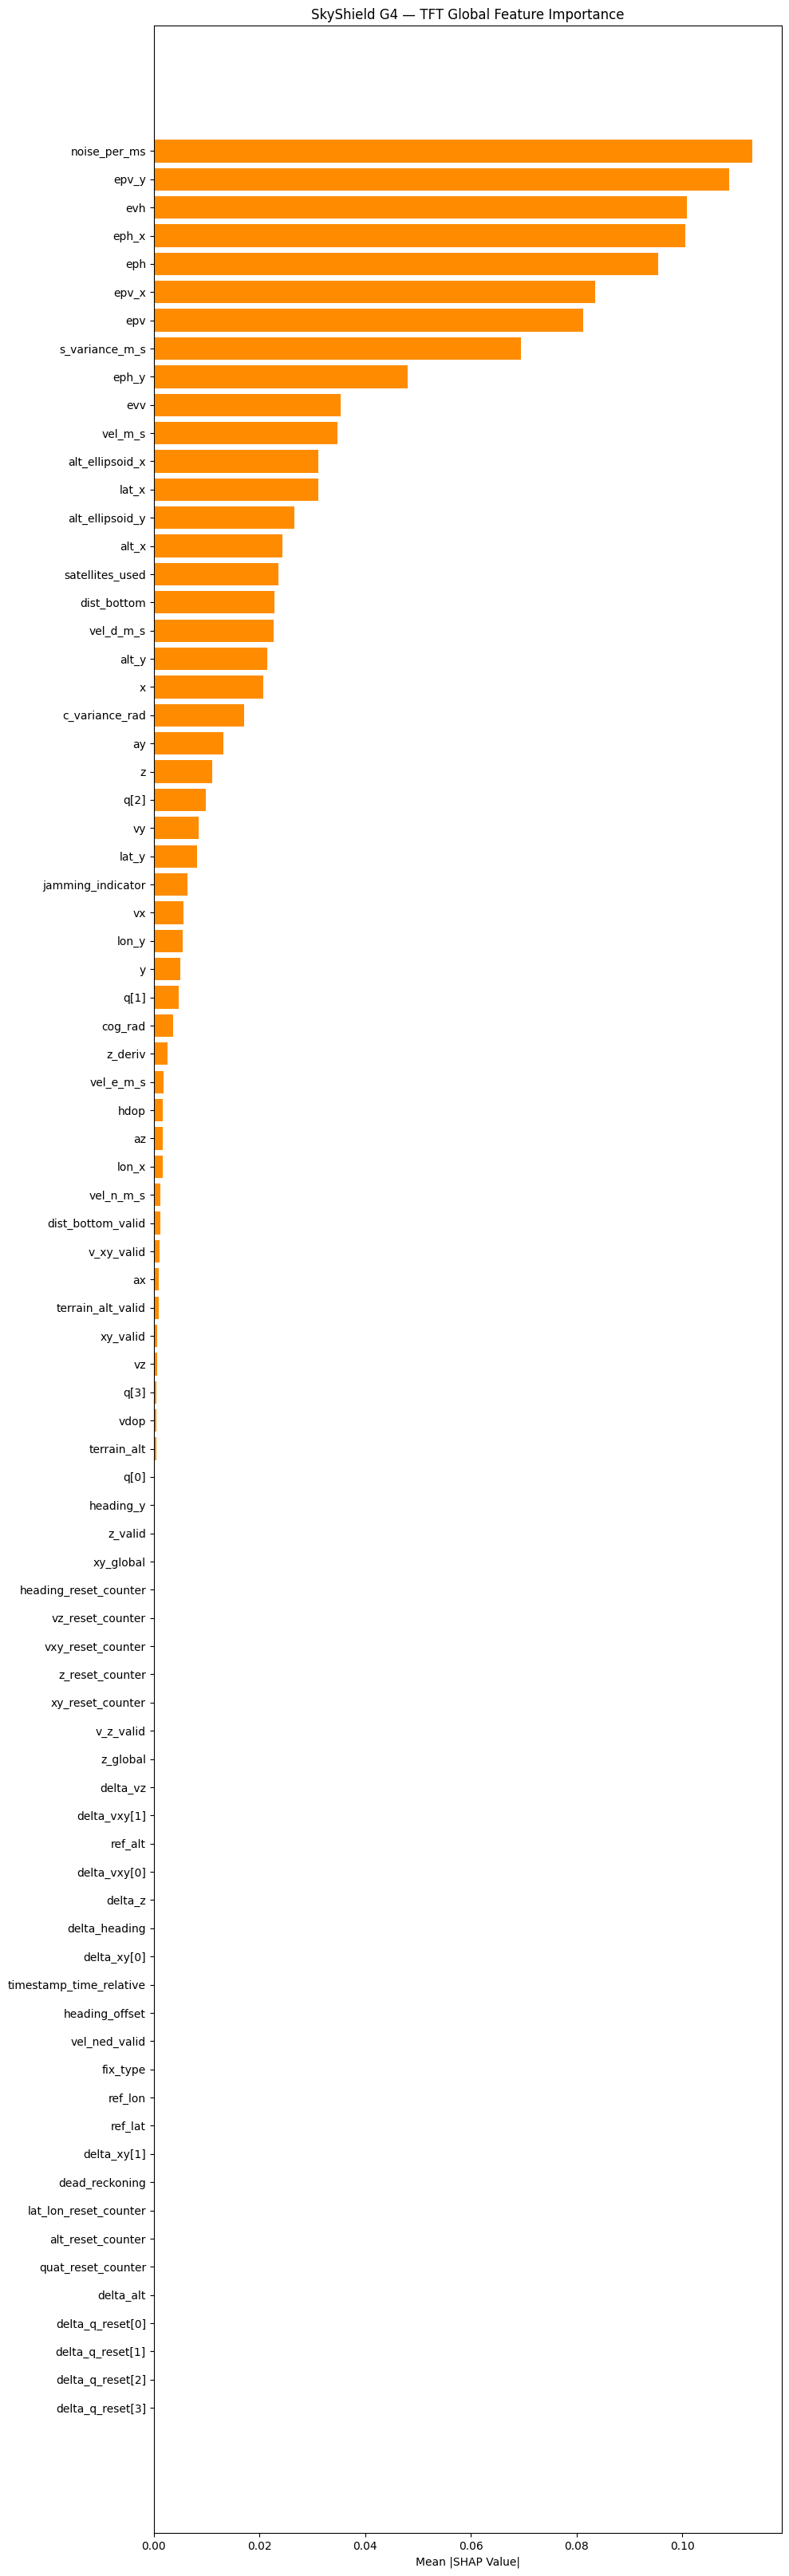

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LayerNorm
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


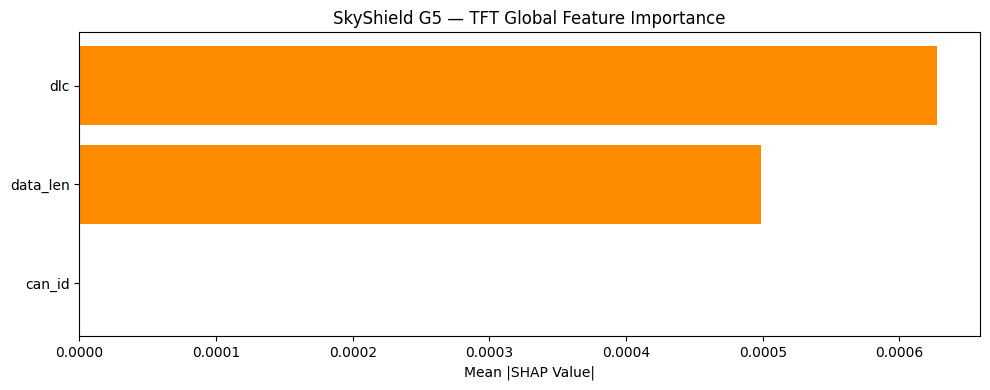

In [22]:
#  TFT SHAP SUMMARY — Fixed Dimensionality for Multi-Class
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import pickle
import os
from google.colab import drive

class TFTWrapper(nn.Module):
    def __init__(self, tft_model, seq_len):
        super().__init__()
        self.model = tft_model
        self.seq_len = seq_len
    def forward(self, x):
        return self.model(x.unsqueeze(1).repeat(1, self.seq_len, 1))

if 'tft_models' not in globals() or not tft_models:
    print("TFT state missing. Re-loading...")
    if not os.path.exists('/content/drive'): drive.mount('/content/drive')
    base = '/content/drive/MyDrive/SkyShield_Datasets'
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    class CustomTFT(nn.Module):
        def __init__(self, input_size, hidden_size, num_classes, num_heads=4, dropout=0.1):
            super().__init__()
            self.input_projection = nn.Linear(input_size, hidden_size)
            self.lstm = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size, num_layers=2, batch_first=True, dropout=dropout)
            self.attention = nn.MultiheadAttention(embed_dim=hidden_size, num_heads=num_heads, dropout=dropout, batch_first=True)
            self.gate = nn.Sequential(nn.Linear(hidden_size * 2, hidden_size), nn.Sigmoid())
            self.norm = nn.LayerNorm(hidden_size)
            self.classifier = nn.Sequential(nn.Linear(hidden_size, hidden_size // 2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_size // 2, num_classes))
        def forward(self, x):
            x = self.input_projection(x)
            lstm_out, _ = self.lstm(x)
            attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
            gate_w = self.gate(torch.cat([lstm_out, attn_out], dim=-1))
            gated = gate_w * lstm_out + (1 - gate_w) * attn_out
            return self.classifier(self.norm(gated)[:, -1, :])

    group_configs = {'G1': {'input_size': 12, 'hidden_size': 64}, 'G2': {'input_size': 9, 'hidden_size': 64}, 'G3': {'input_size': 7, 'hidden_size': 128}, 'G4': {'input_size': 81, 'hidden_size': 64}, 'G5': {'input_size': 3, 'hidden_size': 64}}
    tft_models, tft_scalers, tft_les = {}, {}, {}
    for gname, cfg in group_configs.items():
        try:
            with open(f'{base}/tft_scaler_{gname.lower()}.pkl', 'rb') as f: tft_scalers[gname] = pickle.load(f)
            with open(f'{base}/tft_le_{gname.lower()}.pkl', 'rb') as f: tft_les[gname] = pickle.load(f)
            m = CustomTFT(cfg['input_size'], cfg['hidden_size'], len(tft_les[gname].classes_)).to(device)
            m.load_state_dict(torch.load(f'{base}/tft_{gname.lower()}.pth', map_location=device))
            m.eval(); tft_models[gname] = m
        except Exception as e: print(f"Error loading {gname}: {e}")

if 'deep_explainers' not in globals() or not deep_explainers:
    print("Initializing DeepExplainer objects...")
    deep_explainers = {}
    for gname, model in tft_models.items():
        X_sc, _, _ = prepare_features(datasets[gname], tft_scalers[gname], n_features=group_configs[gname]['input_size'])
        bg_idx = np.random.choice(len(X_sc), size=min(100, len(X_sc)), replace=False)
        bg_t = torch.tensor(X_sc[bg_idx].astype(np.float32)).to(device)
        deep_explainers[gname] = shap.DeepExplainer(TFTWrapper(model, 50).to(device), bg_t)

EXPLAIN_N = 50
for gname, explainer in deep_explainers.items():
    X_sc, _, feat_cols = prepare_features(datasets[gname], tft_scalers[gname], n_features=group_configs[gname]['input_size'])
    idx = np.random.choice(len(X_sc), size=min(EXPLAIN_N, len(X_sc)), replace=False)
    X_t = torch.tensor(X_sc[idx].astype(np.float32)).to(device)

    sv = explainer.shap_values(X_t, check_additivity=False)

    if isinstance(sv, list):

        mean_abs = np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
    else:

        mean_abs = np.abs(sv).mean(axis=(0, 2)) if sv.ndim == 3 else np.abs(sv).mean(axis=0)

    sorted_i = np.argsort(mean_abs)[::-1]

    plt.figure(figsize=(10, max(4, len(feat_cols) * 0.4)))
    plt.barh(range(len(feat_cols)), mean_abs[sorted_i][::-1], color='darkorange')
    plt.yticks(range(len(feat_cols)), [feat_cols[i] for i in sorted_i][::-1])
    plt.xlabel("Mean |SHAP Value|")
    plt.title(f'SkyShield {gname} — TFT Global Feature Importance')
    plt.tight_layout()
    plt.show()

In [26]:
def explain_prediction(group_name, packet_idx, model_type='rf', top_n=10, plot=True):
    # ── Select correct model / explainer ──────────────────
    if model_type == 'rf':
        model = rf_models[group_name]
        scaler = rf_scalers[group_name]
        le = rf_les[group_name]
        explnr = tree_explainers[group_name]
        n_feat = None
    else:
        model = tft_models[group_name]
        scaler = tft_scalers[group_name]
        le = rf_les[group_name]
        explnr = deep_explainers[group_name]
        n_feat = group_configs[group_name]['input_size']

    # ── Prepare sample ────────────────────────────────────
    X_sc, y, feat_cols = prepare_features(datasets[group_name], scaler, n_features=n_feat)
    sample = X_sc[[packet_idx]]

    # ── Predict ───────────────────────────────────────────
    if model_type == 'rf':
        probs = model.predict_proba(sample)[0]
        pred_class = int(np.argmax(probs))
        confidence = probs[pred_class] * 100
    else:
        t = torch.tensor(sample.astype(np.float32)).to(device)
        seq = t.unsqueeze(1).repeat(1, 50, 1)
        with torch.no_grad():
            probs = torch.softmax(model(seq), dim=1).cpu().numpy()[0]
        pred_class = int(np.argmax(probs))
        confidence = probs[pred_class] * 100

    pred_label = le.inverse_transform([pred_class])[0]
    true_label = le.inverse_transform([y[packet_idx]])[0]
    is_attack = str(pred_label).lower() != 'normal'

    # ── Compute SHAP values with proper multi-class indexing ──
    if model_type == 'rf':
        sv = explnr.shap_values(sample)
        # Case 1: List of arrays [class0, class1...]
        if isinstance(sv, list):
            sv_s = sv[pred_class].flatten()
            ev = explnr.expected_value[pred_class]
        # Case 2: 3D array (samples, features, classes)
        elif sv.ndim == 3:
            sv_s = sv[0, :, pred_class]
            ev = explnr.expected_value[pred_class]
        else:
            sv_s = sv[0]
            ev = explnr.expected_value
    else:
        t = torch.tensor(sample.astype(np.float32)).to(device)
        sv = explnr.shap_values(t, check_additivity=False)
        sv_s = sv[pred_class].flatten() if isinstance(sv, list) else sv[0, :, pred_class] if sv.ndim == 3 else sv[0]
        ev = 0.0

    # ── Rank contributions ────────────────────────────────
    # sv_s is now guaranteed to be 1D
    contributions = sorted(zip(feat_cols, sv_s), key=lambda x: abs(x[1]), reverse=True)

    # ── Print explanation block ───────────────────────────
    print('━' * 55)
    print(f'  SKYSHIELD SHAP EXPLANATION — {group_name} [{model_type.upper()}]')
    print('━' * 55)
    print(f'  Packet index  : #{packet_idx}')
    print(f'  True label    : {true_label}')
    print(f'  Predicted     : {pred_label}')
    print(f'  Confidence    : {confidence:.1f}%')
    print(f'  Decision      : {"ATTACK DETECTED" if is_attack else "NORMAL TRAFFIC"}')
    print('  ' + '─' * 51)
    print(f'  Top {top_n} features driving this prediction:')
    for feat, val in contributions[:top_n]:
        direction = '→ attack' if val > 0 else '← normal'
        print(f'  {feat:<35} {val:>+8.4f}   {direction}')
    print('━' * 55)

    if plot:
        exp = shap.Explanation(values=sv_s, base_values=float(ev), data=sample[0], feature_names=feat_cols)
        plt.figure(figsize=(10, 5))
        shap.waterfall_plot(exp, max_display=top_n, show=False)
        plt.title(f'Waterfall: {group_name} | Predicted: {pred_label}')
        plt.show()

    return {"predicted": pred_label, "true": true_label, "contributions": contributions}

 **8 — `explain_prediction()` Unified Helper**

A single function to explain any packet from any group with any model type. Call this during inference to add live explainability to SkyShield alerts.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



DEMO 1 — G1 WiFi Packet, attack (RF)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SKYSHIELD SHAP EXPLANATION — G1 [RF]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Packet index  : #10
  True label    : Normal
  Predicted     : DoS
  Confidence    : 50.0%
  Decision      : ATTACK DETECTED
  ───────────────────────────────────────────────────
  Top 8 features driving this prediction:
  frame_len                            -0.1891   ← normal
  wlan_fc_subtype                      +0.1877   → attack
  frame_number                         +0.1842   → attack
  ip_src                               +0.0888   → attack
  wlan_seq                             +0.0737   → attack
  udp_dstport                          +0.0512   → attack
  ip_dst                               +0.0474   → attack
  wlan_duration                        +0.0180   → attack
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


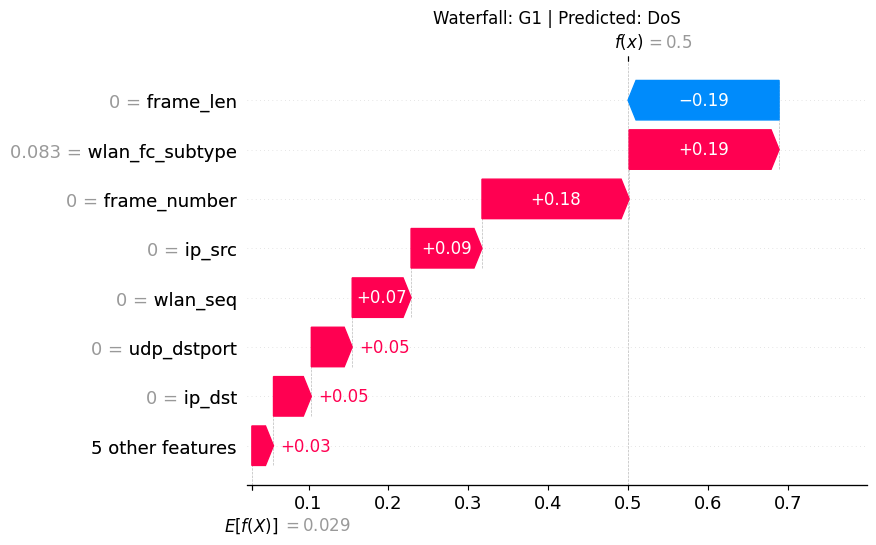

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



DEMO 2 — G2 Network Flow, normal (RF)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SKYSHIELD SHAP EXPLANATION — G2 [RF]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Packet index  : #7200
  True label    : Blackhole
  Predicted     : Fake Landing Packet
  Confidence    : 45.5%
  Decision      : ATTACK DETECTED
  ───────────────────────────────────────────────────
  Top 8 features driving this prediction:
  bwd_pkts_per_sec                     +0.0729   → attack
  bwd_bytes_tot                        +0.0643   → attack
  flow_duration                        +0.0606   → attack
  bwd_pkts_tot                         +0.0542   → attack
  mean_packet_size                     +0.0524   → attack
  fwd_bytes_tot                        +0.0492   → attack
  fwd_pkts_per_sec                     +0.0483   → attack
  bytes_per_sec                        +0.0453   → attack
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


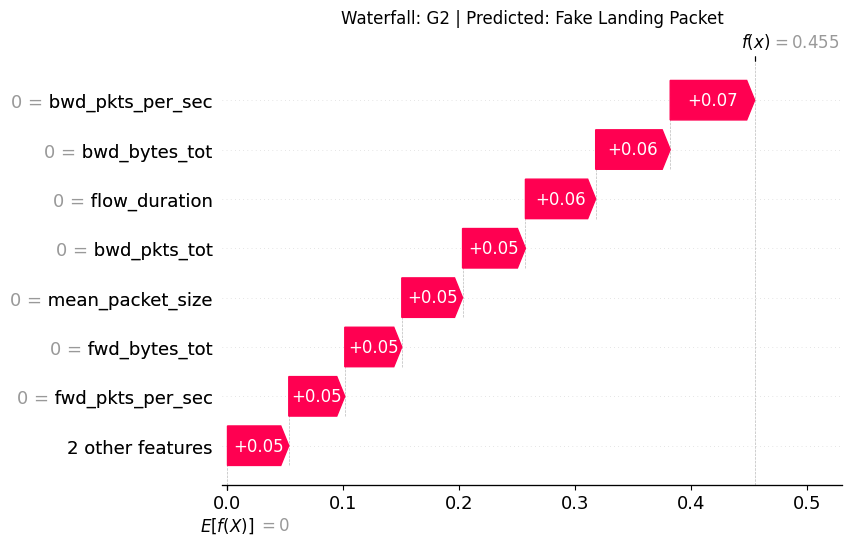

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



DEMO 3 — G3 MAVLink, attack (TFT)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LayerNorm
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SKYSHIELD SHAP EXPLANATION — G3 [TFT]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Packet index  : #0
  True label    : Normal
  Predicted     : Normal
  Confidence    : 100.0%
  Decision      : NORMAL TRAFFIC
  ───────────────────────────────────────────────────
  Top 7 features driving this prediction:
  length                               +5.8704   → attack
  udp_length                           +4.9307   → attack
  udp_srcport                          +0.0421   → attack
  ip_src                               -0.0181   ← normal
  udp_dstport                          +0.0024   → attack
  ip_dst                               +0.0000   ← normal
  ip_proto                             +0.0000   ← normal
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


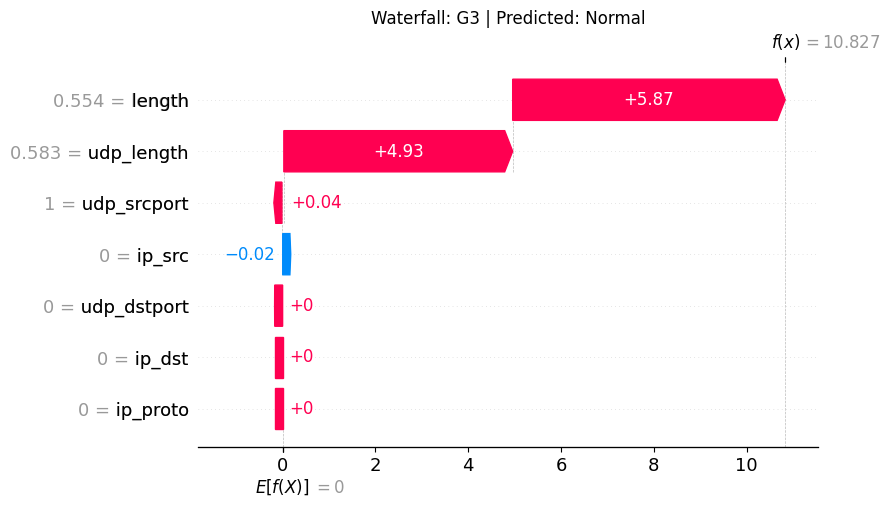

In [31]:
#  DEMO calls — explain real packets across groups

# Demo 1: G1 WiFi — attack packet (RF)
X1, y1, _ = prepare_features(g1, rf_scalers['G1'])
idx_mal_g1 = int(np.where(y1 != 0)[0][10])
print('\n' + '='*58)
print('DEMO 1 — G1 WiFi Packet, attack (RF)')
print('='*58)
result1 = explain_prediction('G1', idx_mal_g1, model_type='rf', top_n=8, plot=True)

# Demo 2: G2 Network Flow — normal packet (RF)
X2, y2, _ = prepare_features(g2, rf_scalers['G2'])
idx_nor_g2 = int(np.where(y2 == 0)[0][0])
print('\n' + '='*58)
print('DEMO 2 — G2 Network Flow, normal (RF)')
print('='*58)
result2 = explain_prediction('G2', idx_nor_g2, model_type='rf', top_n=8, plot=True)

# Demo 3: G3 MAVLink — attack packet (TFT)
X3, y3, _ = prepare_features(g3, tft_scalers['G3'],
                               n_features=group_configs['G3']['input_size'])
idx_mal_g3 = int(np.where(y3 != 0)[0][0])
print('\n' + '='*58)
print('DEMO 3 — G3 MAVLink, attack (TFT)')
print('='*58)
result3 = explain_prediction('G3', idx_mal_g3, model_type='tft', top_n=7, plot=True)

**9 — Batch Explanation Report**

Compute SHAP values for many predictions at once and compare which features differ most between attack and normal traffic.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Top 10 features distinguishing Attack vs Normal — G1:
        feature  mean_shap_attack  mean_shap_normal  abs_diff
wlan_fc_subtype          0.026525          0.003707  0.022818
    udp_dstport          0.028038          0.018915  0.009123
   frame_number          0.053412          0.062025  0.008613
       wlan_seq          0.038963          0.047490  0.008527
      frame_len          0.059241          0.066628  0.007387
  wlan_duration          0.004226          0.001627  0.002599
     udp_length          0.003019          0.001853  0.001166
    udp_srcport          0.002680          0.001839  0.000841
         ip_src          0.035817          0.036463  0.000647
         ip_dst          0.017351          0.017661  0.000310


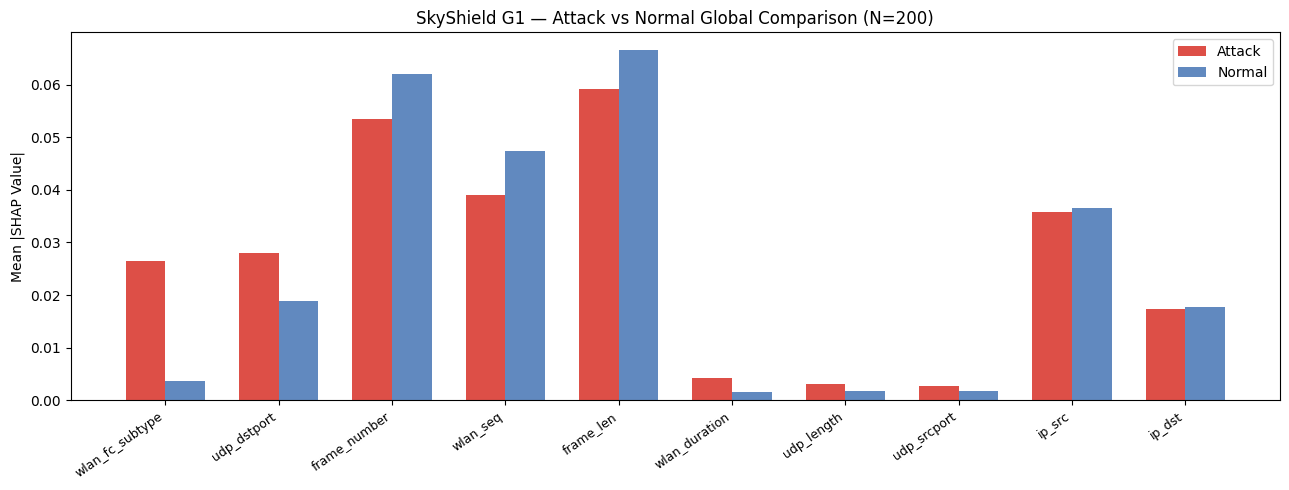

In [28]:
#  BATCH REPORT — Fixed for Multi-Class SHAP Arrays
GNAME   = 'G1'
N_BATCH = 200

X_sc, y, feat_cols = prepare_features(datasets[GNAME], rf_scalers[GNAME])
explainer = tree_explainers[GNAME]

atk_idx = np.where(y != 0)[0][:N_BATCH]
nor_idx = np.where(y == 0)[0][:N_BATCH]

sv_atk = explainer.shap_values(X_sc[atk_idx])
sv_nor = explainer.shap_values(X_sc[nor_idx])

if isinstance(sv_atk, list):

    mean_atk = np.mean([np.abs(s).mean(axis=0) for s in sv_atk], axis=0)
    mean_nor = np.mean([np.abs(s).mean(axis=0) for s in sv_nor], axis=0)
else:

    mean_atk = np.abs(sv_atk).mean(axis=(0, 2)) if sv_atk.ndim == 3 else np.abs(sv_atk).mean(axis=0)
    mean_nor = np.abs(sv_nor).mean(axis=(0, 2)) if sv_nor.ndim == 3 else np.abs(sv_nor).mean(axis=0)

df_cmp = pd.DataFrame({
    'feature'          : feat_cols,
    'mean_shap_attack' : mean_atk,
    'mean_shap_normal' : mean_nor,
    'abs_diff'         : np.abs(mean_atk - mean_nor)
}).sort_values('abs_diff', ascending=False)

print(f'Top 10 features distinguishing Attack vs Normal — {GNAME}:')
print(df_cmp.head(10).to_string(index=False))
df_cmp.to_csv(f'shap_batch_report_{GNAME}.csv', index=False)

top = df_cmp.head(10)
x   = np.arange(len(top))
w   = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, top['mean_shap_attack'], w, label='Attack', color='#d73027', alpha=0.85)
ax.bar(x + w/2, top['mean_shap_normal'], w, label='Normal', color='#4575b4', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(top['feature'], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP Value|', fontsize=10)
ax.set_title(f'SkyShield {GNAME} — Attack vs Normal Global Comparison (N={N_BATCH})')
ax.legend()
plt.tight_layout()
plt.show()

**10 — Enhanced SkyShield Alert with SHAP**

Drop-in replacement for the original `skyshield_alert()` that appends SHAP feature attribution to every alert so analysts immediately know *why* the model fired.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



ENHANCED ALERT DEMO — G1 WiFi (RF)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SKYSHIELD SHAP EXPLANATION — G1 [RF]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Packet index  : #20
  True label    : Normal
  Predicted     : DoS
  Confidence    : 50.0%
  Decision      : ATTACK DETECTED
  ───────────────────────────────────────────────────
  Top 6 features driving this prediction:
  frame_len                            -0.1891   ← normal
  wlan_fc_subtype                      +0.1877   → attack
  frame_number                         +0.1842   → attack
  ip_src                               +0.0888   → attack
  wlan_seq                             +0.0737   → attack
  udp_dstport                          +0.0512   → attack
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


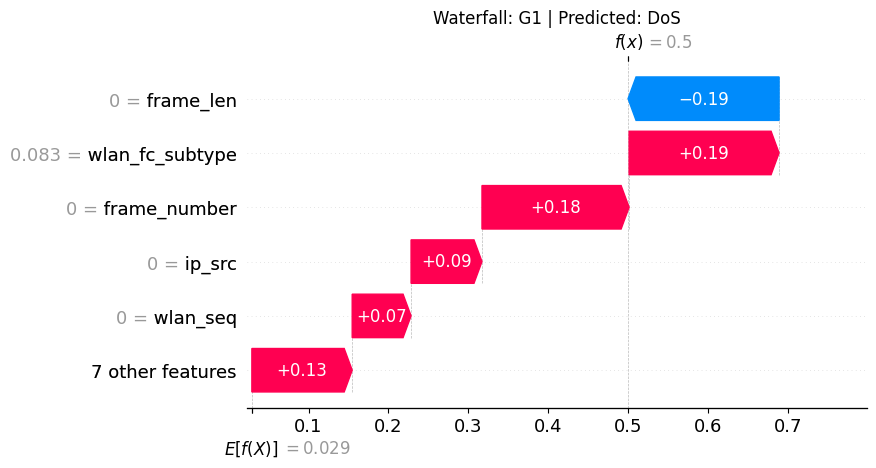

  SHAP ATTRIBUTION
  ───────────────────────────────────────────────────
  Attack signals (features increasing attack probability):
    + wlan_fc_subtype                   SHAP=+0.1877
    + frame_number                      SHAP=+0.1842
    + ip_src                            SHAP=+0.0888
    + wlan_seq                          SHAP=+0.0737
    + udp_dstport                       SHAP=+0.0512
    + ip_dst                            SHAP=+0.0474

  Mitigating factors (reducing attack probability):
    - frame_len                         SHAP=-0.1891
    - ip_proto                          SHAP=-0.0000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


{'predicted': 'DoS',
 'true': 'Normal',
 'contributions': [('frame_len', np.float64(-0.189071362883878)),
  ('wlan_fc_subtype', np.float64(0.1877341203234155)),
  ('frame_number', np.float64(0.18419121689945547)),
  ('ip_src', np.float64(0.08877781420024254)),
  ('wlan_seq', np.float64(0.07369984903113604)),
  ('udp_dstport', np.float64(0.05116354573053898)),
  ('ip_dst', np.float64(0.04736549861385879)),
  ('wlan_duration', np.float64(0.017992613928888526)),
  ('udp_length', np.float64(0.003982089751551073)),
  ('udp_srcport', np.float64(0.003770092699576315)),
  ('ip_ttl', np.float64(0.001371018363587308)),
  ('ip_proto', np.float64(-4.959724026681843e-05))]}

In [32]:
#  skyshield_alert_with_shap()
#
#  Enhanced alert that extends the original skyshield_alert()
#  with a SHAP attribution block. For each alert it prints:
#    - Which features are acting as attack signals
#    - Which features are suppressing the attack probability
def skyshield_alert_with_shap(group_name, packet_idx,
                               model_type='rf', top_n=5, plot=True):
    """
    Drop-in replacement for skyshield_alert() with SHAP attribution.

    Parameters — identical to explain_prediction().
    Returns the same dict as explain_prediction().
    """
    result = explain_prediction(
        group_name, packet_idx,
        model_type=model_type, top_n=top_n, plot=plot)

    # Calculate is_attack locally since explain_prediction return dict lacks it
    is_attack = str(result['predicted']).lower() != 'normal'

    print('  SHAP ATTRIBUTION')
    print('  ' + '─' * 51)
    if is_attack:
        triggers = [(f, v) for f, v in result['contributions'] if v > 0][:top_n]
        mitigators = [(f, v) for f, v in result['contributions'] if v < 0][:3]
        print('  Attack signals (features increasing attack probability):')
        for feat, val in triggers:
            print(f'    + {feat:<33} SHAP={val:+.4f}')
        if mitigators:
            print('\n  Mitigating factors (reducing attack probability):')
            for feat, val in mitigators:
                print(f'    - {feat:<33} SHAP={val:+.4f}')
    else:
        print('  No dominant attack signals. Normal traffic indicators:')
        norm = [(f, v) for f, v in result['contributions'] if v < 0][:top_n]
        for feat, val in norm:
            print(f'    o {feat:<33} SHAP={val:+.4f}')
    print('━' * 55)
    return result

X1, y1, _ = prepare_features(g1, rf_scalers['G1'])
demo_idx   = int(np.where(y1 != 0)[0][20])

print('\n' + '='*58)
print('ENHANCED ALERT DEMO — G1 WiFi (RF)')
print('='*58)
skyshield_alert_with_shap('G1', demo_idx, model_type='rf', top_n=6, plot=True)

---
## Interpretation Guide

### Reading SHAP values
| SHAP value | Meaning |
|---|---|
| Large positive | Feature strongly pushes prediction toward predicted class |
| Large negative | Feature strongly pulls prediction away from predicted class |
| Near zero | Feature had negligible effect on this prediction |

### Common network features — what high SHAP means
| Feature | High SHAP → attack signal when… |
|---|---|
| `packet_size` | Unusually large (exfiltration) or tiny (C2 beaconing) |
| `protocol_type` | Rare or unexpected protocol number |
| `src_port` / `dst_port` | Non-standard or ephemeral port abuse |
| `flow_duration` | Very short (scan) or very long (persistent session) |
| `failed_logins` | Any count > 0 (brute-force indicator) |
| `traffic_frequency` | Burst rates suggest flooding / DDoS |
| `byte_rate` | Disproportionate to connection duration |

### Saved outputs
| File | Content |
|---|---|
| `shap_summary_G*_rf.png` | Global feature importance bar chart (RF) |
| `shap_summary_G*_tft.png` | Global feature importance bar chart (TFT) |
| `shap_beeswarm_G*_rf.png` | Beeswarm dot plot (RF) |
| `shap_waterfall_G*_*.png` | Per-prediction waterfall plot |
| `shap_force_G*.png` | Force plot (static PNG) |
| `shap_dependence_G*_rf.png` | Feature interaction dependence plots |
| `shap_batch_comparison_G*.png` | Attack vs Normal comparison chart |
| `shap_batch_report_G*.csv` | Full feature contribution table |